In [1]:
import sys
sys.path.insert(0, '..')
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from utils.climate_projections import load_scenario_env
from config import GRID_GPKG

Base grid: 61,060 cells
Baseline: 61,060 cells, cols with temp: ['temp_mean_12', 'temp_mean_10', 'temp_mean_05', 'temp_mean_06']

=== load_scenario_env: SSP1-2.6 / end ===
  [LOAD] temp   → grid_env_temp_ssp1_2_6_end.gpkg  (24 columns)
  [LOAD] sal    → grid_env_sal_ssp1_2_6_end.gpkg  (24 columns)
  [LOAD] chla   → grid_env_chla_ssp1_2_6_end.gpkg  (24 columns)
  [LOAD] flow   → grid_env_flow_ssp1_2_6_end.gpkg  (36 columns)
  [OK] env_source = CMIP6:ssp1_2_6:end
  [OK] Grid ready for Module 2 (61,060 cells)

=== load_scenario_env: SSP5-8.5 / end ===
  [LOAD] temp   → grid_env_temp_ssp5_8_5_end.gpkg  (24 columns)
  [LOAD] sal    → grid_env_sal_ssp5_8_5_end.gpkg  (24 columns)
  [LOAD] chla   → grid_env_chla_ssp5_8_5_end.gpkg  (24 columns)
  [LOAD] flow   → grid_env_flow_ssp5_8_5_end.gpkg  (36 columns)
  [OK] env_source = CMIP6:ssp5_8_5:end
  [OK] Grid ready for Module 2 (61,060 cells)

SSP1-2.6 cols with temp: ['temp_mean_12', 'temp_mean_10', 'temp_mean_05', 'temp_mean_06']
SSP5-8.5 cols 

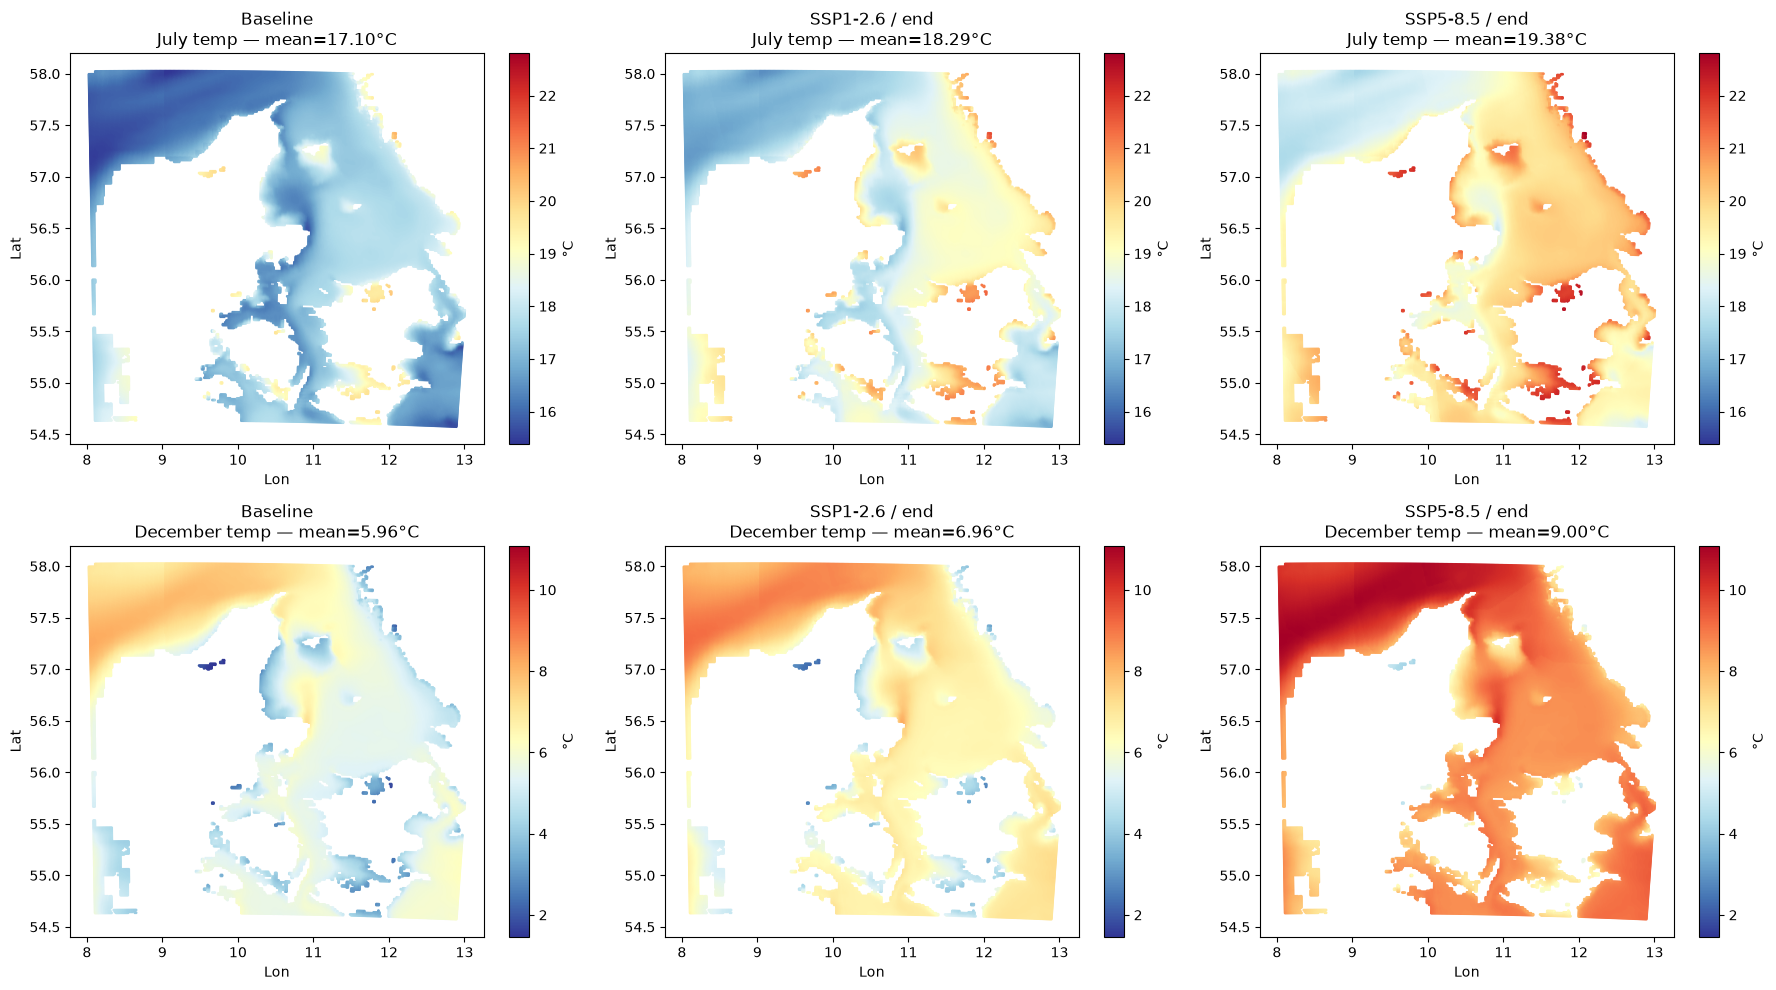


Saved: scenario_sanity_check.png


In [2]:
# Load base grid
grid = gpd.read_file(GRID_GPKG)
print(f'Base grid: {len(grid):,} cells')

# Load baseline temp from baseline.gpkg for comparison
from config import BASELINE_GPKG
baseline = gpd.read_file(BASELINE_GPKG)
print(f'Baseline: {len(baseline):,} cells, cols with temp: {[c for c in baseline.columns if "temp_mean" in c][:4]}')

# Load two scenarios
ssp126 = load_scenario_env(grid, ssp='ssp1_2_6', period='end')
ssp585 = load_scenario_env(grid, ssp='ssp5_8_5', period='end')

print(f'\nSSP1-2.6 cols with temp: {[c for c in ssp126.columns if "temp_mean" in c][:4]}')
print(f'SSP5-8.5 cols with temp: {[c for c in ssp585.columns if "temp_mean" in c][:4]}')

# Compare July (07) and December (12) temperatures
for month, label in [('07', 'July'), ('12', 'December')]:
    col = f'temp_mean_{month}'
    if col not in baseline.columns:
        print(f'Column {col} not in baseline')
        continue
    b  = baseline[col].dropna()
    s1 = ssp126[col].dropna() if col in ssp126.columns else None
    s5 = ssp585[col].dropna() if col in ssp585.columns else None
    print(f'\n{label} ({col}):')
    print(f'  Baseline:   mean={b.mean():.3f}°C  min={b.min():.2f}  max={b.max():.2f}')
    if s1 is not None:
        print(f'  SSP1-2.6:   mean={s1.mean():.3f}°C  min={s1.min():.2f}  max={s1.max():.2f}  Δmean={s1.mean()-b.mean():+.3f}')
    if s5 is not None:
        print(f'  SSP5-8.5:   mean={s5.mean():.3f}°C  min={s5.min():.2f}  max={s5.max():.2f}  Δmean={s5.mean()-b.mean():+.3f}')

# Plot comparison maps
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
scenarios = [
    (baseline, 'Baseline'),
    (ssp126,   'SSP1-2.6 / end'),
    (ssp585,   'SSP5-8.5 / end'),
]

for row, (month, mlabel) in enumerate([('07', 'July'), ('12', 'December')]):
    col = f'temp_mean_{month}'
    vmin = min(df[col].min() for df, _ in scenarios if col in df.columns)
    vmax = max(df[col].max() for df, _ in scenarios if col in df.columns)
    for col_idx, (df, title) in enumerate(scenarios):
        ax = axes[row, col_idx]
        if col not in df.columns:
            ax.set_title(f'{title}\n{mlabel} — NO DATA')
            continue
        pts = df.geometry.centroid.to_crs('EPSG:4326')
        sc = ax.scatter(pts.x, pts.y, c=df[col], s=1,
                        cmap='RdYlBu_r', vmin=vmin, vmax=vmax)
        plt.colorbar(sc, ax=ax, label='°C')
        mean_val = df[col].mean()
        ax.set_title(f'{title}\n{mlabel} temp — mean={mean_val:.2f}°C')
        ax.set_xlabel('Lon'); ax.set_ylabel('Lat')

plt.tight_layout()
plt.savefig('scenario_sanity_check.png', dpi=100, bbox_inches='tight')
plt.show()
print('\nSaved: scenario_sanity_check.png')